# Blinkit Data Analytics — Delivery analysis
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 8. Delivery performance

### 8.1 Delivery status against actual minutes

In [7]:
q('''
SELECT delivery_status,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct,
       round(AVG(delay_min), 2)  AS avg_minutes_vs_promise,
       MIN(delay_min) AS min_minutes, MAX(delay_min) AS max_minutes,
       COUNT(*) FILTER (WHERE delay_min > 0) AS arrived_after_promise
FROM f_sales GROUP BY 1 ORDER BY orders DESC ''')

,delivery_status,orders,share_pct,avg_minutes_vs_promise,min_minutes,max_minutes,arrived_after_promise
0,On Time,3470,69.40,0.01,-5,5,1568
1,Slightly Delayed,1037,20.74,10.52,6,15,1037
2,Significantly Delayed,493,9.86,22.84,16,30,493


### 8.2 Promise accuracy summary

In [8]:
q('''
SELECT COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_by_status_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min <= 0) / COUNT(*), 2)        AS on_or_before_promise_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 0) / COUNT(*), 2)         AS after_promise_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 10) / COUNT(*), 2)        AS more_than_10_min_late_pct,
       round(AVG(delay_min) FILTER (WHERE delay_min > 0), 2)                      AS avg_delay_when_late,
       round(quantile_cont(delay_min, 0.5), 1)  AS p50_minutes,
       round(quantile_cont(delay_min, 0.9), 1)  AS p90_minutes,
       round(quantile_cont(delay_min, 0.95), 1) AS p95_minutes
FROM f_sales ''')

,orders,on_time_by_status_pct,on_or_before_promise_pct,after_promise_pct,more_than_10_min_late_pct,avg_delay_when_late,p50_minutes,p90_minutes,p95_minutes
0,5000,69.40,38.04,61.96,20.14,8.69,2.00,15.00,23.00


### 8.3 Distribution of minutes against promise

In [9]:
q('''
SELECT CASE WHEN delay_min <= -5 THEN 'a. 5 or more minutes early'
            WHEN delay_min < 0   THEN 'b. 1 to 4 minutes early'
            WHEN delay_min = 0   THEN 'c. exactly on promise'
            WHEN delay_min <= 5  THEN 'd. 1 to 5 minutes late'
            WHEN delay_min <= 10 THEN 'e. 6 to 10 minutes late'
            WHEN delay_min <= 20 THEN 'f. 11 to 20 minutes late'
            ELSE 'g. more than 20 minutes late' END AS band,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct,
       round(SUM(revenue), 0) AS revenue
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,band,orders,share_pct,revenue
0,a. 5 or more minutes early,316,6.32,"325,553.00"
1,b. 1 to 4 minutes early,1247,24.94,"1,262,082.00"
2,c. exactly on promise,339,6.78,"327,300.00"
3,d. 1 to 5 minutes late,1568,31.36,"1,536,949.00"
4,e. 6 to 10 minutes late,523,10.46,"497,734.00"
5,f. 11 to 20 minutes late,674,13.48,"688,053.00"
6,g. more than 20 minutes late,333,6.66,"334,745.00"


### 8.4 On-time rate by state

In [10]:
q('''
SELECT state, zone, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 10) / COUNT(*), 2)        AS very_late_pct,
       round(AVG(delay_min), 2) AS avg_minutes_vs_promise,
       round(AVG(distance_km), 2) AS avg_distance_km,
       RANK() OVER (ORDER BY 1.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) DESC) AS rank_on_time
FROM f_sales GROUP BY state, zone HAVING COUNT(*) >= 30 ORDER BY on_time_pct DESC ''')

,state,zone,orders,on_time_pct,very_late_pct,avg_minutes_vs_promise,avg_distance_km,rank_on_time
0,Kerala,South,106,76.42,16.04,3.86,2.69,1
1,Rajasthan,North,178,73.60,18.54,4.00,2.74,2
2,Odisha,East,83,73.49,14.46,3.89,2.68,3
3,Gujarat,West,204,72.06,20.10,4.80,2.65,4
4,Punjab,North,114,71.93,21.05,3.87,2.64,5
5,Jammu and Kashmir,North,32,71.88,18.75,4.59,2.66,6
6,Madhya Pradesh,Central,318,71.70,17.92,3.92,2.66,7
7,Karnataka,South,217,71.43,21.66,4.44,2.73,8
8,Maharashtra,West,491,70.67,17.72,4.29,2.73,9
9,Assam,North East,163,70.55,19.02,4.06,2.62,10


### 8.5 On-time rate by month

In [11]:
q('''
SELECT strftime(order_month, '%Y-%m') AS month, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*)
             - LAG(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*)) OVER (ORDER BY order_month), 2) AS change_vs_prev_month
FROM f_sales GROUP BY order_month ORDER BY order_month ''')

,month,orders,on_time_pct,avg_minutes,change_vs_prev_month
0,2023-03,120,66.67,4.68,NaN
1,2023-04,238,68.07,4.47,1.40
2,2023-05,276,68.84,4.41,0.77
3,2023-06,232,75.86,3.45,7.02
4,2023-07,244,70.08,3.93,-5.78
5,2023-08,285,70.88,3.80,0.80
6,2023-09,262,72.14,3.91,1.26
7,2023-10,254,73.62,3.91,1.48
8,2023-11,265,63.40,5.43,-10.23
9,2023-12,268,66.79,5.16,3.39


### 8.6 On-time rate by hour and time slot

In [12]:
q('''
SELECT order_time_slot, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes,
       round(AVG(distance_km), 2) AS avg_distance_km,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY 1 ORDER BY on_time_pct ''')

,order_time_slot,orders,on_time_pct,avg_minutes,avg_distance_km,avg_rating
0,Afternoon,1030,68.74,4.44,2.72,3.32
1,Morning,1445,69.34,4.56,2.68,3.32
2,Night,1640,69.39,4.40,2.73,3.35
3,Evening,885,70.28,4.34,2.76,3.40


### 8.7 Delay against distance

In [13]:
q('''
SELECT CASE WHEN distance_km < 1 THEN 'a. under 1 km' WHEN distance_km < 2 THEN 'b. 1-2 km'
            WHEN distance_km < 5 THEN 'c. 2-5 km' ELSE 'd. 5 km and above' END AS distance_band,
       COUNT(*) AS orders, round(AVG(delay_min), 2) AS avg_minutes_vs_promise,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 0) / COUNT(*), 2) AS late_pct,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,distance_band,orders,avg_minutes_vs_promise,late_pct,avg_rating
0,a. under 1 km,536,4.01,59.89,3.38
1,b. 1-2 km,1195,4.75,62.76,3.32
2,c. 2-5 km,3264,4.41,62.01,3.35
3,d. 5 km and above,5,2.40,60.00,3.00


### 8.8 Correlation between distance and delay

In [14]:
d = q('SELECT delay_min, distance_km, revenue, rating FROM f_sales')
pearson = stats.pearsonr(d.distance_km, d.delay_min)
spearman = stats.spearmanr(d.distance_km, d.delay_min)
pd.DataFrame([{'test':'Pearson correlation (distance vs delay)','statistic':round(pearson[0],4),'p_value':round(pearson[1],4)},
              {'test':'Spearman correlation (distance vs delay)','statistic':round(spearman[0],4),'p_value':round(spearman[1],4)},
              {'test':'Pearson correlation (order value vs delay)','statistic':round(stats.pearsonr(d.revenue, d.delay_min)[0],4),
               'p_value':round(stats.pearsonr(d.revenue, d.delay_min)[1],4)}])

,test,statistic,p_value
0,Pearson correlation (distance vs delay),0.00,0.77
1,Spearman correlation (distance vs delay),0.00,0.77
2,Pearson correlation (order value vs delay),0.00,0.97


### 8.9 Proposed delivery promise by zone

In [15]:
q('''
SELECT zone, COUNT(*) AS orders,
       round(AVG(date_diff('minute', order_ts, promised_ts)), 1)  AS current_promise_min,
       round(AVG(date_diff('minute', order_ts, actual_ts)), 1)    AS actual_avg_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.80), 0) AS p80_actual_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.90), 0) AS p90_actual_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.95), 0) AS p95_actual_min
FROM orders o JOIN geo g ON g.area = o.area GROUP BY zone ORDER BY p90_actual_min DESC ''')

,zone,orders,current_promise_min,actual_avg_min,p80_actual_min,p90_actual_min,p95_actual_min
0,East,1042,15.10,19.50,26.00,32.00,38.00
1,North,617,15.00,19.50,27.00,32.00,37.00
2,Central,1009,14.90,19.40,26.00,32.00,39.00
3,South,1405,15.00,19.40,26.00,32.00,37.00
4,West,695,14.90,19.40,25.00,31.00,37.00
5,North East,232,14.90,19.20,26.00,31.00,35.00


### 8.10 Share of orders met under each candidate promise

In [16]:
q('''
WITH t AS (SELECT date_diff('minute', order_ts, actual_ts) AS actual_min FROM orders)
SELECT p AS promise_minutes,
       round(100.0 * COUNT(*) FILTER (WHERE actual_min <= p) / COUNT(*), 2) AS orders_met_pct
FROM t, (SELECT unnest([10, 12, 15, 18, 20, 25, 30]) AS p) GROUP BY p ORDER BY p ''')

,promise_minutes,orders_met_pct
0,10,12.14
1,12,20.40
2,15,37.76
3,18,54.60
4,20,64.02
5,25,79.32
6,30,88.00


### 8.11 Late delivery model

In [17]:
import statsmodels.api as sm
model_df = q('''
SELECT is_late_minutes AS late, distance_km, order_hour, revenue, is_weekend,
       CASE WHEN zone = 'South' THEN 1 ELSE 0 END AS zone_south,
       CASE WHEN zone = 'North' THEN 1 ELSE 0 END AS zone_north,
       CASE WHEN zone = 'East'  THEN 1 ELSE 0 END AS zone_east
FROM f_sales WHERE distance_km IS NOT NULL ''')
X = sm.add_constant(model_df[['distance_km','order_hour','revenue','is_weekend','zone_south','zone_north','zone_east']].astype(float))
logit = sm.Logit(model_df.late.astype(float), X).fit(disp=0)
pd.DataFrame({'coefficient':logit.params.round(4),'p_value':logit.pvalues.round(4),
              'odds_ratio':np.exp(logit.params).round(4)})

,coefficient,p_value,odds_ratio
const,0.54,0.00,1.72
distance_km,0.00,0.88,1.00
order_hour,0.00,0.70,1.00
revenue,-0.00,0.39,1.00
is_weekend,0.01,0.88,1.01
zone_south,-0.05,0.51,0.95
zone_north,-0.13,0.18,0.88
zone_east,-0.11,0.18,0.90


### 8.12 Model fit

In [18]:
pd.DataFrame([{'observations':int(logit.nobs),'pseudo_r_squared':round(logit.prsquared,4),
               'log_likelihood':round(logit.llf,1),'llr_p_value':round(logit.llr_pvalue,4),
               'significant_predictors':int((logit.pvalues < 0.05).sum())}])

,observations,pseudo_r_squared,log_likelihood,llr_p_value,significant_predictors
0,5000,0.00,"-3,319.40",0.80,1


## Charts

### 16.3 Minutes against the promised time

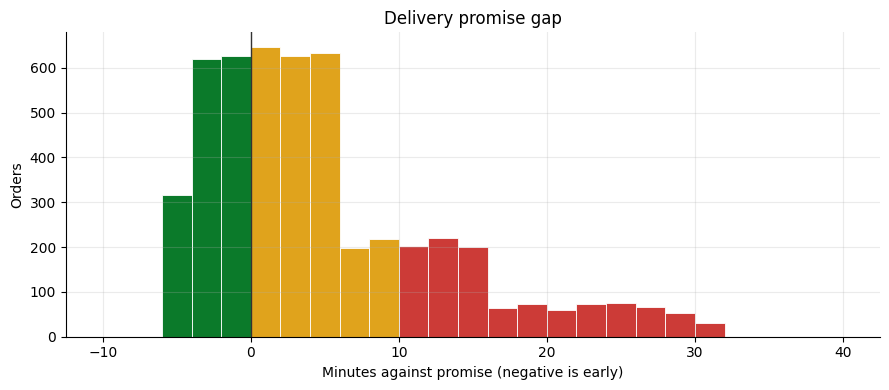

In [19]:
d = q('SELECT delay_min FROM f_sales')
clip = d.delay_min.clip(-10, 40)
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(-10, 42, 2)
counts, edges, patches = ax.hist(clip, bins=bins, color=GREEN, edgecolor='white', linewidth=.6)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(GREEN if left < 0 else GOLD if left < 10 else RED)
ax.axvline(0, color='#333', lw=1)
ax.set_xlabel('Minutes against promise (negative is early)'); ax.set_ylabel('Orders')
ax.set_title('Delivery promise gap'); plt.tight_layout(); plt.show()

### 16.9 On-time rate by state

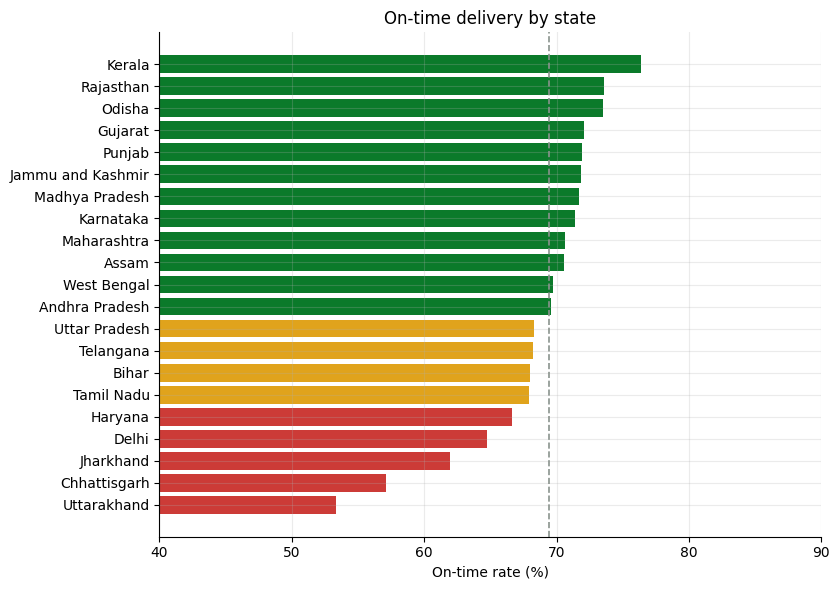

In [20]:
st = q('''
SELECT state, COUNT(*) AS orders,
       100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) AS on_time
FROM f_sales GROUP BY 1 HAVING COUNT(*) >= 30 ORDER BY on_time ''')
overall = q('SELECT 100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) AS ot FROM f_sales').ot[0]
fig, ax = plt.subplots(figsize=(8.5, 6))
colors = [RED if v < overall - 2 else GOLD if v < overall else GREEN for v in st.on_time]
ax.barh(st.state, st.on_time, color=colors)
ax.axvline(overall, color=GREY, ls='--', lw=1.2)
ax.set_xlim(40, 90); ax.set_xlabel('On-time rate (%)'); ax.set_title('On-time delivery by state')
plt.tight_layout(); plt.show()